# 02 — Variables Instrumentales (IV) y 2SLS
**Autores clave:** Wright (1928) · Theil (1953) · Basmann (1957) · Angrist & Krueger (1991) · Imbens & Angrist (1994) · Angrist & Pischke (2009) *Mostly Harmless Econometrics*, Cap. 4

## El problema de la endogeneidad
OLS requiere $E[u|X] = 0$. Esto se viola cuando:
- Hay **variables omitidas** correlacionadas con $X$ (habilidad no observada)
- Hay **causalidad inversa** (simultaneidad)
- Hay **error de medición** en $X$

## Solución: Instrumento $Z$
Un instrumento válido satisface:
1. **Relevancia:** $\text{Cov}(Z, X) \neq 0$ — testeable con F-test de primera etapa (F > 10, Stock & Yogo, 2005)
2. **Exogeneidad (exclusión):** $\text{Cov}(Z, u) = 0$ — no testeable, requiere argumento económico

## Estimador IV (caso exactamente identificado)
$$\hat{\beta}_{IV} = \frac{\text{Cov}(Z, y)}{\text{Cov}(Z, X)} = (Z^\top X)^{-1} Z^\top y$$

## 2SLS (sobre-identificado)
- **Etapa 1:** $\hat{X} = Z(Z^\top Z)^{-1}Z^\top X$ (proyectar $X$ sobre $Z$)
- **Etapa 2:** $\hat{\beta}_{2SLS} = (\hat{X}^\top X)^{-1}\hat{X}^\top y$

## LATE — Local Average Treatment Effect (Imbens & Angrist, 1994)
IV no recupera el ATE global sino el efecto **sobre los compliers** — unidades cuyo tratamiento cambia al cambiar el instrumento:
$$\tau_{LATE} = \frac{\text{ITT}_y}{\text{ITT}_D} = \frac{E[Y|Z=1] - E[Y|Z=0]}{E[D|Z=1] - E[D|Z=0]}$$

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

# Diseño: retorno a la educación (Angrist & Krueger, 1991)
# Endogeneidad: habilidad no observada afecta tanto educación como salario
# Instrumento: trimestre de nacimiento (quarter of birth) → edad al empezar escuela
n = 2000

# Habilidad no observada (confounder)
ability = np.random.normal(0, 1, n)

# Instrumento: quarter of birth (0/1, simplificado)
Z = np.random.binomial(1, 0.5, n).astype(float)

# Primera etapa: Z aumenta educación ~0.5 años (ley de asistencia obligatoria)
educ = 12 + 0.8*ability + 0.5*Z + np.random.normal(0, 1.5, n)

# Ecuación estructural: β_educ verdadero = 0.10
# Pero ability también entra → OLS está sesgado hacia arriba
log_wage = 1.0 + 0.10*educ + 0.30*ability + np.random.normal(0, 0.5, n)

df = pd.DataFrame({'log_wage': log_wage, 'educ': educ, 'Z': Z, 'ability': ability})
print(f'Dataset: {n} observaciones')
print(f'Correlación educ-ability: {df["educ"].corr(df["ability"]):.3f}  (fuente de endogeneidad)')
print(f'Correlación Z-educ:       {df["Z"].corr(df["educ"]):.3f}  (relevancia del instrumento)')
print(f'Correlación Z-ability:    {df["Z"].corr(df["ability"]):.3f}  (exogeneidad del instrumento)')

Dataset: 2000 observaciones
Correlación educ-ability: 0.465  (fuente de endogeneidad)
Correlación Z-educ:       0.185  (relevancia del instrumento)
Correlación Z-ability:    0.056  (exogeneidad del instrumento)


## 1 — OLS sesgado vs IV consistente

In [2]:
X_base = sm.add_constant(df[['educ']])

# OLS (sesgado: ignora ability)
mod_ols = sm.OLS(df['log_wage'], X_base).fit()

# OLS con ability (referencia — si pudiéramos observarla)
mod_oracle = sm.OLS(df['log_wage'], sm.add_constant(df[['educ', 'ability']])).fit()

# IV manual: Wald estimator (caso exactamente identificado)
wald_iv = (df.groupby('Z')['log_wage'].mean().diff().iloc[-1] /
           df.groupby('Z')['educ'].mean().diff().iloc[-1])

# 2SLS con statsmodels
endog  = df['log_wage']
exog   = sm.add_constant(df['educ'])
instr  = sm.add_constant(df['Z'])
mod_iv = IV2SLS(endog, exog, instr).fit()

print('Comparación de estimadores — β_educ verdadero = 0.10')
print('─' * 60)
print(f'  OLS (sesgado, sin controlar ability):  {mod_ols.params["educ"]:.4f}  ← sesgo positivo')
print(f'  OLS oracle (con ability observable):   {mod_oracle.params["educ"]:.4f}')
print(f'  Wald IV (estimador directo):            {wald_iv:.4f}')
print(f'  2SLS:                                  {mod_iv.params["educ"]:.4f}')
print()
print('Primera etapa (relevancia del instrumento):')
first_stage = sm.OLS(df['educ'], sm.add_constant(df['Z'])).fit()
print(f'  Coef Z → educ: {first_stage.params["Z"]:.4f}  F={first_stage.fvalue:.2f}  p={first_stage.f_pvalue:.4f}')
print(f'  F > 10 (Stock & Yogo 2005): {first_stage.fvalue > 10}')

Comparación de estimadores — β_educ verdadero = 0.10
────────────────────────────────────────────────────────────
  OLS (sesgado, sin controlar ability):  0.1868  ← sesgo positivo
  OLS oracle (con ability observable):   0.1131
  Wald IV (estimador directo):            0.1592
  2SLS:                                  0.1592

Primera etapa (relevancia del instrumento):
  Coef Z → educ: 0.6294  F=70.84  p=0.0000
  F > 10 (Stock & Yogo 2005): True


## 2 — Primera etapa: diagnóstico de instrumento débil

> **Stock & Yogo (2005):** Con F < 10 en la primera etapa, el estimador IV tiene sesgo sustancial hacia OLS y los intervalos de confianza estándar tienen cobertura inferior al nominal.

Sesgo de IV según fuerza del instrumento (β verdadero = 0.10)
 strength   F_mean  iv_mean  iv_sd  ols_mean
     0.05   1.3771  -0.1708 6.4505    0.1829
     0.10   2.9275   0.0970 1.3366    0.1831
     0.30  16.5342   0.0868 0.1045    0.1816
     0.50  45.4240   0.0977 0.0527    0.1813
     1.00 173.8863   0.0983 0.0257    0.1767
     2.00 692.2175   0.0998 0.0120    0.1616


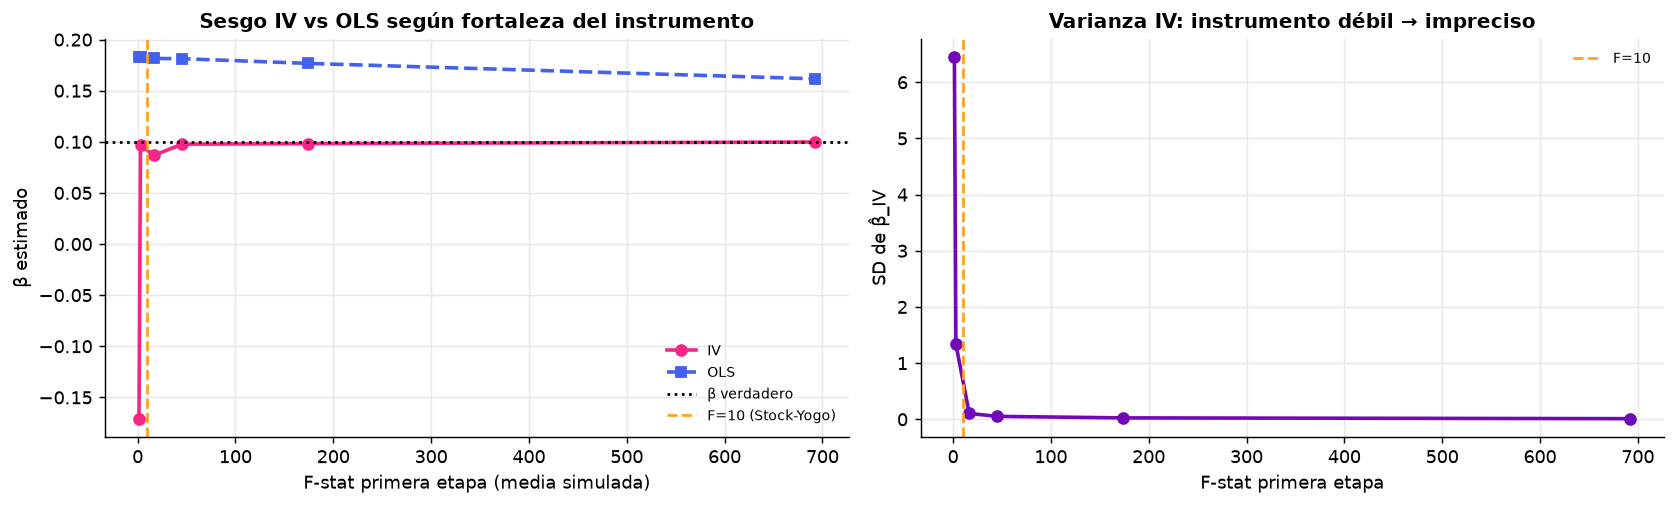

In [3]:
# Simular cómo varía el sesgo IV según la fuerza del instrumento
B = 500
instrument_strengths = [0.05, 0.1, 0.3, 0.5, 1.0, 2.0]  # coef de Z en primera etapa

results = []
for strength in instrument_strengths:
    betas_iv, betas_ols, fstats = [], [], []
    for _ in range(B):
        ab  = np.random.normal(0, 1, n)
        z   = np.random.binomial(1, 0.5, n).astype(float)
        ed  = 12 + 0.8*ab + strength*z + np.random.normal(0, 1.5, n)
        lw  = 1.0 + 0.10*ed + 0.30*ab + np.random.normal(0, 0.5, n)
        # OLS
        b_ols = sm.OLS(lw, sm.add_constant(ed)).fit().params[1]
        # IV Wald
        g = pd.Series(z); y_s = pd.Series(lw); x_s = pd.Series(ed)
        b_iv = (y_s.groupby(g).mean().diff().iloc[-1] /
                x_s.groupby(g).mean().diff().iloc[-1])
        # F-stat primera etapa
        fstat = sm.OLS(ed, sm.add_constant(z)).fit().fvalue
        betas_iv.append(b_iv); betas_ols.append(b_ols); fstats.append(fstat)
    results.append({'strength': strength, 'F_mean': np.mean(fstats),
                    'iv_mean': np.mean(betas_iv), 'iv_sd': np.std(betas_iv),
                    'ols_mean': np.mean(betas_ols)})

res_df = pd.DataFrame(results)
print('Sesgo de IV según fuerza del instrumento (β verdadero = 0.10)')
print(res_df[['strength', 'F_mean', 'iv_mean', 'iv_sd', 'ols_mean']].round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(res_df['F_mean'], res_df['iv_mean'], 'o-', color='#f72585', linewidth=2, label='IV')
axes[0].plot(res_df['F_mean'], res_df['ols_mean'], 's--', color='#4361ee', linewidth=2, label='OLS')
axes[0].axhline(0.10, color='black', linestyle=':', linewidth=1.5, label='β verdadero')
axes[0].axvline(10, color='#ff9f1c', linestyle='--', linewidth=1.5, label='F=10 (Stock-Yogo)')
axes[0].set_xlabel('F-stat primera etapa (media simulada)')
axes[0].set_ylabel('β estimado')
axes[0].set_title('Sesgo IV vs OLS según fortaleza del instrumento')
axes[0].legend(fontsize=8)

axes[1].plot(res_df['F_mean'], res_df['iv_sd'], 'o-', color='#7209b7', linewidth=2)
axes[1].axvline(10, color='#ff9f1c', linestyle='--', linewidth=1.5, label='F=10')
axes[1].set_xlabel('F-stat primera etapa')
axes[1].set_ylabel('SD de β̂_IV')
axes[1].set_title('Varianza IV: instrumento débil → impreciso')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3 — LATE: ¿Quiénes son los compliers?

Con tratamiento binario $D$ e instrumento binario $Z$ (Imbens & Angrist, 1994):

| Tipo | Comportamiento | Identifica IV |
|---|---|---|
| Compliers | $D(Z=1)=1, D(Z=0)=0$ | Sí — LATE |
| Always-takers | $D(Z=1)=D(Z=0)=1$ | No |
| Never-takers | $D(Z=1)=D(Z=0)=0$ | No |
| Defiers | $D(Z=1)=0, D(Z=0)=1$ | No (asumimos monotonía) |

LATE — Imbens & Angrist (1994)
  ATE verdadero (todos):     2.6443
  LATE verdadero (compliers): 5.0000
  Wald IV estimado:           6.5837
  ITT_y: 1.7460  ITT_d (proporción compliers): 0.2652

Composición de la muestra:
type
complier    0.351
never       0.308
always      0.242
defier      0.099


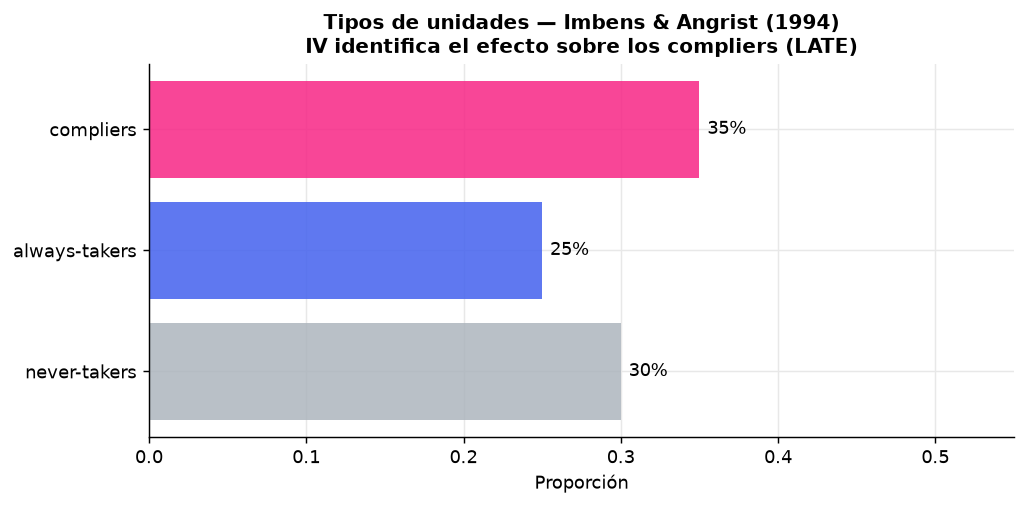

In [4]:
# Simular tipos de unidades con tratamiento binario
np.random.seed(42)
n2 = 3000

# Tipos latentes (no observables)
type_prob = [0.35, 0.25, 0.30, 0.10]  # compliers, always-takers, never-takers, defiers=0
unit_type = np.random.choice(['complier', 'always', 'never', 'defier'],
                              n2, p=type_prob)

Z2 = np.random.binomial(1, 0.5, n2).astype(float)

# Tratamiento observado según tipo
D = np.where(unit_type == 'always', 1,
    np.where(unit_type == 'never',  0,
    np.where(unit_type == 'complier', Z2,
             1 - Z2)))  # defiers

# Efectos heterogéneos: compliers tienen mayor retorno
te = np.where(unit_type == 'complier', 5.0,
     np.where(unit_type == 'always', 2.0, 1.0))

Y0 = np.random.normal(10, 2, n2)   # outcome sin tratamiento
Y1 = Y0 + te                        # outcome con tratamiento
Y  = np.where(D == 1, Y1, Y0)

df2 = pd.DataFrame({'Y': Y, 'D': D, 'Z': Z2, 'type': unit_type, 'te': te})

# LATE por Wald
ITT_y = df2.groupby('Z')['Y'].mean().diff().iloc[-1]
ITT_d = df2.groupby('Z')['D'].mean().diff().iloc[-1]
late_wald = ITT_y / ITT_d

true_late = df2[df2['type'] == 'complier']['te'].mean()
true_ate  = df2['te'].mean()

print('LATE — Imbens & Angrist (1994)')
print(f'  ATE verdadero (todos):     {true_ate:.4f}')
print(f'  LATE verdadero (compliers): {true_late:.4f}')
print(f'  Wald IV estimado:           {late_wald:.4f}')
print(f'  ITT_y: {ITT_y:.4f}  ITT_d (proporción compliers): {ITT_d:.4f}')
print()
print('Composición de la muestra:')
print(df2['type'].value_counts(normalize=True).round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
tipos  = ['never-takers', 'always-takers', 'compliers']
props  = [type_prob[2], type_prob[1], type_prob[0]]
colors = ['#adb5bd', '#4361ee', '#f72585']
bars   = ax.barh(tipos, props, color=colors, alpha=0.85)
for bar, prop in zip(bars, props):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{prop:.0%}', va='center', fontsize=10)
ax.set_xlabel('Proporción')
ax.set_title('Tipos de unidades — Imbens & Angrist (1994)\nIV identifica el efecto sobre los compliers (LATE)')
ax.set_xlim(0, 0.55)
plt.tight_layout()
plt.show()

## 4 — Test de Hausman: ¿Es endógena la variable?

**Hausman (1978):** si OLS es consistente, no debe diferir sistemáticamente de IV. Si difieren significativamente → evidencia de endogeneidad.

In [5]:
# Durbin-Wu-Hausman test (equivalente a incluir residual primera etapa)
# Regress: y = X*beta + gamma*v_hat + e, donde v_hat = residual de primera etapa
first_stage = sm.OLS(df['educ'], sm.add_constant(df['Z'])).fit()
v_hat = first_stage.resid

X_aug = sm.add_constant(pd.DataFrame({'educ': df['educ'], 'v_hat': v_hat}))
mod_aug = sm.OLS(df['log_wage'], X_aug).fit()

gamma_coef = mod_aug.params['v_hat']
gamma_p    = mod_aug.pvalues['v_hat']

print('Test de Endogeneidad — Durbin-Wu-Hausman')
print('H₀: educ es exógena (OLS consistente)')
print('─' * 50)
print(f'Coef. residual primera etapa (γ): {gamma_coef:.4f}')
print(f'p-value:                          {gamma_p:.4f}')
print(f'Decisión: {"Rechazar H₀ — educ es ENDÓGENA, usar IV" if gamma_p < 0.05 else "No rechazar H₀ — OLS es consistente"}')
print()
print('Resumen de estimadores:')
print(f'  β_OLS: {mod_ols.params["educ"]:.4f}  β_IV: {mod_iv.params["educ"]:.4f}  β verdadero: 0.10')

Test de Endogeneidad — Durbin-Wu-Hausman
H₀: educ es exógena (OLS consistente)
──────────────────────────────────────────────────
Coef. residual primera etapa (γ): 0.0286
p-value:                          0.4886
Decisión: No rechazar H₀ — OLS es consistente

Resumen de estimadores:
  β_OLS: 0.1868  β_IV: 0.1592  β verdadero: 0.10


## Resumen

| Concepto | Fórmula / Regla | Referencia |
|---|---|---|
| Estimador IV | $(Z^\top X)^{-1}Z^\top y$ | Wright (1928) |
| Instrumento relevante | F > 10 en primera etapa | Stock & Yogo (2005) |
| Instrumento exógeno | $\text{Cov}(Z,u)=0$ | No testeable |
| LATE | ITT_y / ITT_d | Imbens & Angrist (1994) |
| Test endogeneidad | Durbin-Wu-Hausman | Hausman (1978) |

**Referencias:**
- Angrist, J.D. & Krueger, A.B. (1991). Does compulsory school attendance affect schooling and earnings? *QJE*, 106(4).
- Imbens, G.W. & Angrist, J.D. (1994). Identification and estimation of local average treatment effects. *Econometrica*, 62(2).
- Stock, J.H. & Yogo, M. (2005). Testing for weak instruments in linear IV regression. In *Identification and Inference for Econometric Models*. Cambridge UP.
- Angrist, J.D. & Pischke, J.S. (2009). *Mostly Harmless Econometrics*. Princeton UP.

**Siguiente:** `03_regression_discontinuity.ipynb`